# Tidal boundaries

**What this shows:** the options of `TidalDataset` and what they do to the tide at the
open boundary: which constituents, nodal corrections, the tidal potential,
extrapolation and a mean water level.

**Prerequisites:** [Tutorial 3: Tides and open boundaries](../tutorial/03_tides_and_open_boundaries.ipynb).

**You will learn:**

- how many constituents a tide needs
- what nodal corrections change in `bctides.in`
- when the tidal potential and extrapolation matter
- how to raise the mean water level at the boundary

**Data used:** `hgrid.gr3` and `tides/`. The runs need Docker and are skipped
without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "tidal_boundaries"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
ALL = ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"]

grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)
nml = NML(
    param=Param(
        core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 15, "ihfskip": 720},
        schout={"iof_hydro__1": 1, "iof_hydro__26": 0},
    )
)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-03T00:00", interval="1h")


def schism_config(tides: TidalDataset) -> SCHISMConfig:
    """The tidal model of Tutorial 3 with the given tides."""
    conditions = SCHISMDataBoundaryConditions(
        tidal_data=tides,
        default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
    )
    return SCHISMConfig(
        grid=grid, data=SCHISMData(boundary_conditions=conditions), nml=nml
    )


def tides(**options) -> TidalDataset:
    """The TPXO9 tides around Perth with the given options."""
    return TidalDataset(
        tidal_database=DATA_DIR / "tides", tidal_model="TPXO9-perth", **options
    )


def bctides_header(config: SCHISMConfig, run_id: str) -> list[str]:
    """The constituent lines of bctides.in for a configuration."""
    modelrun = ModelRun(run_id=run_id, period=period, output_dir=OUT_DIR, config=config)
    lines = (Path(modelrun()) / "bctides.in").read_text().splitlines()
    end = next(i for i, line in enumerate(lines) if "!nope" in line)
    return lines[:end]

## 1. Which constituents

`constituents` takes a list, or `"major"` for the eight main ones (M2, S2, N2, K2,
K1, O1, P1, Q1). The database must contain them. More constituents give a more
complete tide at the boundary; the main eight usually carry almost all of it. Off
Perth, the diurnal K1 and O1 and the semidiurnal M2 and S2 dominate.

## 2. Nodal corrections

The amplitude and phase of each constituent vary over the 18.6-year cycle of the
Moon's orbit. The *nodal factor* scales the amplitude and the *equilibrium argument*
sets the phase for the start of the run; `bctides.in` gives both for each
constituent. Without corrections, the factors are 1 and the tide is that of an
average year. In January 2023 that would be 9 to 15% off for K1, O1 and Q1, and 25%
for K2.

In [2]:
for nodal in (False, True):
    header = bctides_header(schism_config(tides(constituents=ALL, nodal_corrections=nodal)), f"nodal_{nodal}")
    start = next(i for i, line in enumerate(header) if "!nbfr" in line)
    print(f"nodal_corrections={nodal}:")
    for name, values in zip(header[start + 3 :: 2], header[start + 4 :: 2]):
        _, factor, argument = values.split()
        print(f"  {name:3s} factor {float(factor):.3f}, argument {float(argument):6.1f}°")

nodal_corrections=False:
  m2  factor 1.000, argument  147.5°
  s2  factor 1.000, argument    0.0°
  n2  factor 1.000, argument   60.1°
  k2  factor 1.000, argument  200.8°
  k1  factor 1.000, argument   10.4°
  o1  factor 1.000, argument  137.1°
  p1  factor 1.000, argument  349.6°
  q1  factor 1.000, argument   49.7°


nodal_corrections=True:
  m2  factor 0.972, argument  146.1°
  s2  factor 1.000, argument    0.0°
  n2  factor 0.972, argument   58.7°
  k2  factor 1.245, argument  190.0°
  k1  factor 1.092, argument    5.3°
  o1  factor 1.149, argument  143.0°
  p1  factor 1.000, argument  349.6°
  q1  factor 1.150, argument   55.7°


## 3. The tidal potential

The tide is generated by the Moon and Sun pulling on the whole ocean, not only at the
open boundary. With `tidal_potential=True` (the default), SCHISM also applies this
force inside the domain, in water deeper than `cutoff_depth` (50 m by default).
For a small coastal domain like this one, almost all of the tide comes in through the
boundary; for large domains, the potential matters.

## 4. Extrapolation

Global tide models are coarse near the coast: the nearest cells to a boundary node
where the open boundary meets land may be land in the tide model. With
`extrapolate_tides=True`, pyTMD takes the nearest wet value within
`extrapolation_distance` (km) instead of leaving the node without a tide.

## 5. Mean water level

The tide oscillates around zero. `mean_dynamic_topography` adds a constant offset at
the boundary, written as a `z0` constituent: for example the mean sea level of an
ocean model relative to the mesh's datum. It can also vary along the boundary, from
a dataset.

## 6. Three runs

All eight constituents; only M2 and K1; and all eight with a mean level 0.2 m higher.

In [3]:
variants = {
    "eight constituents": tides(constituents=ALL, nodal_corrections=True),
    "M2 and K1": tides(constituents=["M2", "K1"], nodal_corrections=True),
    "eight, mean level +0.2 m": tides(
        constituents=ALL, nodal_corrections=True, mean_dynamic_topography=0.2
    ),
}


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


backend = DockerConfig(image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6)
results = {}
for number, (name, tidal_data) in enumerate(variants.items()):
    modelrun = ModelRun(
        run_id=f"run{number}", period=period, output_dir=OUT_DIR,
        config=schism_config(tidal_data),
    )  # fmt: skip
    workspace = Path(modelrun())
    if docker_available():
        modelrun.run(backend, workspace_dir=workspace)
    if run_completed(workspace):
        results[name] = xr.open_mfdataset(
            sorted((workspace / "outputs").glob("out2d_*.nc")),
            data_vars="minimal", coords="minimal", compat="override",
        )  # fmt: skip
print(f"Completed: {list(results)}")

Completed: ['eight constituents', 'M2 and K1', 'eight, mean level +0.2 m']


At Fremantle, M2 and K1 alone miss much of the tide: the diurnal O1 and the
semidiurnal S2 are nearly as large. The mean level offset raises the whole curve by
0.2 m once the ramp is over.

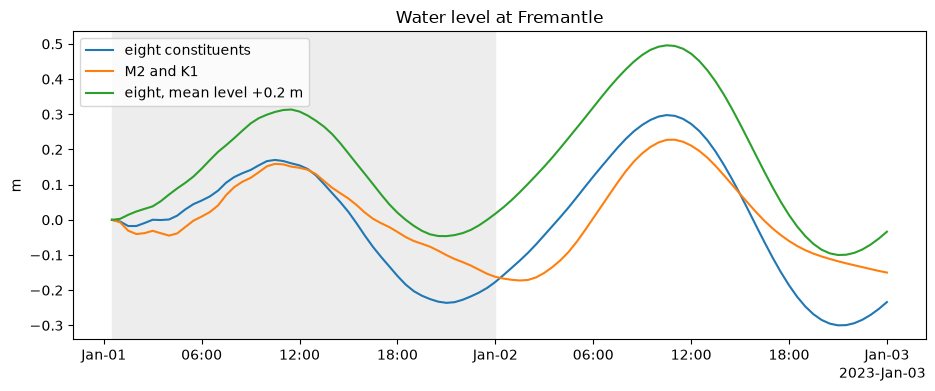

In [4]:
if len(results) == len(variants):
    first = next(iter(results.values()))
    x, y = first.SCHISM_hgrid_node_x.values, first.SCHISM_hgrid_node_y.values
    node = np.argmin((x - 115.72) ** 2 + (y + 32.06) ** 2)
    fig, ax = plt.subplots(figsize=(11, 4))
    for name, result in results.items():
        result.elevation[:, node].plot(ax=ax, label=name)
    ax.axvspan(first.time[0].values, np.datetime64("2023-01-02"), color="0.93")
    ax.set(title="Water level at Fremantle", ylabel="m", xlabel="")
    ax.legend()

## Summary

- Use enough constituents: here the main eight; check the amplitudes in your area.
- Turn on `nodal_corrections` for the tide of the run's dates.
- The tidal potential matters for large domains; `cutoff_depth` limits it to deep
  water.
- `extrapolate_tides` fills boundary nodes where the tide model has land.
- `mean_dynamic_topography` sets a mean level at the boundary.